#Project 10


**Custom-Object Character Recognition(OCR) on AWS (Google Drive/ Cloud Storage)**

1.**Set Up the Environment**

● Task 1.1:Set Up the Environment (on Google Colab)
○ Mount Google Drive to store your dataset, model weights, and output files
○ Define folder structure in Drive: datasets/, models/, results.

● Task 1.2: Set Up SageMaker Notebook Instance
○ Launch a SageMaker notebook instance.
○ Install necessary dependencies: Tesseract, PyTesseract, OpenCV, and YOLOv3.
○ Ensure that the notebook instance has access to the S3 bucket.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# set path variable
DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"

# quick verify
!echo "Using DRIVE_ROOT = $DRIVE_ROOT"
!ls -la "$DRIVE_ROOT"


Using DRIVE_ROOT = /content/drive/MyDrive/project 10/Dataset_OCR
total 5942
drwx------ 2 root root  4096 Nov  9 14:10 datasets
drwx------ 2 root root  4096 Nov  9 14:10 models
drwx------ 2 root root  4096 Nov  9 14:10 notebooks
drwx------ 2 root root  4096 Nov  9 14:10 results
drwx------ 2 root root  4096 Nov  9 14:10 src
-rw------- 1 root root 61427 Nov  3 17:01 thyrocare_0_1001.jpg
-rw------- 1 root root 61551 Nov  3 17:01 thyrocare_0_1174.jpg
-rw------- 1 root root 58617 Nov  3 17:01 thyrocare_0_122.jpg
-rw------- 1 root root 61331 Nov  3 17:01 thyrocare_0_123.jpg
-rw------- 1 root root 61399 Nov  3 17:01 thyrocare_0_1248.jpg
-rw------- 1 root root 73532 Nov  3 17:01 thyrocare_0_1374.jpg
-rw------- 1 root root 54728 Nov  3 17:01 thyrocare_0_1433.jpg
-rw------- 1 root root 61506 Nov  3 17:01 thyrocare_0_1711.jpg
-rw------- 1 root root 73949 Nov  3 17:01 thyrocare_0_1861.jpg
-rw------- 1 root root 64419 Nov  3 17:01 thyrocare_0_1915.jpg
-rw------- 1 root root 60556 Nov  3 17:01 thyroc

In [3]:
# If images are directly in DRIVE_ROOT (as image direct show)
!ls -la "$DRIVE_ROOT" | sed -n '1,120p'

# If you want only the datasets folder:
!ls -la "$DRIVE_ROOT/datasets" | sed -n '1,120p'


total 5942
drwx------ 2 root root  4096 Nov  9 14:10 datasets
drwx------ 2 root root  4096 Nov  9 14:10 models
drwx------ 2 root root  4096 Nov  9 14:10 notebooks
drwx------ 2 root root  4096 Nov  9 14:10 results
drwx------ 2 root root  4096 Nov  9 14:10 src
-rw------- 1 root root 61427 Nov  3 17:01 thyrocare_0_1001.jpg
-rw------- 1 root root 61551 Nov  3 17:01 thyrocare_0_1174.jpg
-rw------- 1 root root 58617 Nov  3 17:01 thyrocare_0_122.jpg
-rw------- 1 root root 61331 Nov  3 17:01 thyrocare_0_123.jpg
-rw------- 1 root root 61399 Nov  3 17:01 thyrocare_0_1248.jpg
-rw------- 1 root root 73532 Nov  3 17:01 thyrocare_0_1374.jpg
-rw------- 1 root root 54728 Nov  3 17:01 thyrocare_0_1433.jpg
-rw------- 1 root root 61506 Nov  3 17:01 thyrocare_0_1711.jpg
-rw------- 1 root root 73949 Nov  3 17:01 thyrocare_0_1861.jpg
-rw------- 1 root root 64419 Nov  3 17:01 thyrocare_0_1915.jpg
-rw------- 1 root root 60556 Nov  3 17:01 thyrocare_0_2177.jpg
-rw------- 1 root root 72238 Nov  3 17:01 thyrocar

In [4]:
# create code folder
!mkdir -p "$DRIVE_ROOT/code"
!ls -la "$DRIVE_ROOT"


total 5946
drwx------ 2 root root  4096 Nov 10 01:56 code
drwx------ 5 root root  4096 Nov  9 14:10 datasets
drwx------ 2 root root  4096 Nov  9 14:10 models
drwx------ 2 root root  4096 Nov  9 14:10 notebooks
drwx------ 2 root root  4096 Nov  9 14:10 results
drwx------ 2 root root  4096 Nov  9 14:10 src
-rw------- 1 root root 61427 Nov  3 17:01 thyrocare_0_1001.jpg
-rw------- 1 root root 61551 Nov  3 17:01 thyrocare_0_1174.jpg
-rw------- 1 root root 58617 Nov  3 17:01 thyrocare_0_122.jpg
-rw------- 1 root root 61331 Nov  3 17:01 thyrocare_0_123.jpg
-rw------- 1 root root 61399 Nov  3 17:01 thyrocare_0_1248.jpg
-rw------- 1 root root 73532 Nov  3 17:01 thyrocare_0_1374.jpg
-rw------- 1 root root 54728 Nov  3 17:01 thyrocare_0_1433.jpg
-rw------- 1 root root 61506 Nov  3 17:01 thyrocare_0_1711.jpg
-rw------- 1 root root 73949 Nov  3 17:01 thyrocare_0_1861.jpg
-rw------- 1 root root 64419 Nov  3 17:01 thyrocare_0_1915.jpg
-rw------- 1 root root 60556 Nov  3 17:01 thyrocare_0_2177.jpg
-rw

In [ ]:
# Install Tesseract and python libries
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr libtesseract-dev
!pip install -q pytesseract pillow opencv-python-headless numpy pandas imutils tqdm


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 125080 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Selecting previously unselected package libleptonica-dev.
Preparing to unpack .../libleptonica-dev_1.82.0-3build1_amd64.deb ...
Unpacking libleptonica-dev (1.82.0-3build1) ...
Selecting previously unselected package libtesseract-dev:amd64.
Preparing to unpack .../libtesseract-dev_4.1.1-2.1build1_amd64.deb ...
Unpacking libtesseract-dev:amd64 (4.1.1-2.1build1) ...
Setting up libleptonica-dev (1.82.0-3build1) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Setting up libtesseract-dev:amd64 (4.1.1-2.1build1) ...
Processing triggers for ma

In [6]:
pip install pytesseract

In [8]:
# OCR Test image
from PIL import Image
import pytesseract
import os

# choose an example filename
example = "/content/drive/MyDrive/project 10/Dataset_OCR/thyrocare_0_1001.jpg"

# construct path: if images are in DRIVE_ROOT directly
img_path = os.path.join(DRIVE_ROOT, example)
print("Trying image:", img_path)
assert os.path.exists(img_path), f"File not found: {img_path}"

img = Image.open(img_path)
# basic OCR
text = pytesseract.image_to_string(img, config='--psm 6')
print("---- OCR output (first 500 chars) ----")
print(text[:500])


Trying image: /content/drive/MyDrive/project 10/Dataset_OCR/thyrocare_0_1001.jpg
---- OCR output (first 500 chars) ----
; —_—__——__
= a Thyrocare

1 II, RAA/36, Raghunathpur,

——_Conporate Office: Tryrocare Technologies Limited 9 0-37/3, TTC MIBC, Turnhe. Navi Mumar 400703
© @ 0x 3079 0000/4125 2575 © 5591855066 EB weliness~rnyrocare cam Bwwwtnyrocarecom 4
mane ASHO SENGUITA 19 sawets coUscreD ar:
merey ser Iparastsi)eaurana nEDICOS AND CTY
(iain Ro oka Sea

TesvaseeD + oor abs otse
ae recoroey vane ons
25-08 VITAMIN 0 (TOTAL) cura x ra
farwence oes
ee ame
TeSUerCANCY 20-030 nt
Seems: soe nn
Soca: seo
Tee ee saw 


In [10]:
img_path = os.path.join(DRIVE_ROOT, "datasets", "/content/drive/MyDrive/project 10/Dataset_OCR/datasets/processed/images")
print(os.path.exists(img_path))


True


In [11]:
# save ocr csv example
import pandas as pd
rows = []
rows.append({"filename": example, "ocr_text": text})
df = pd.DataFrame(rows)
out_csv = os.path.join(DRIVE_ROOT, "results", "ocr_sample.csv")
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
!ls -la "$DRIVE_ROOT/results"



Saved: /content/drive/MyDrive/project 10/Dataset_OCR/results/ocr_sample.csv
total 14
drwx------ 2 root root 4096 Nov  9 14:10 crops
-rw------- 1 root root   77 Nov  9 14:23 environment_info.csv
drwx------ 2 root root 4096 Nov  9 14:10 evaluation
-rw------- 1 root root 1389 Nov 10 02:00 ocr_sample.csv
drwx------ 2 root root 4096 Nov  9 14:10 validation


In [12]:
%%bash
CSV_PATH="/content/drive/MyDrive/project 10/Dataset_OCR/results/ocr_sample.csv"
if [ -f "$CSV_PATH" ]; then
  echo "Showing first 50 lines from: $CSV_PATH"
  sed -n '1,50p' "$CSV_PATH"
else
  echo "CSV not found at $CSV_PATH; check above ls outputs."
fi

Showing first 50 lines from: /content/drive/MyDrive/project 10/Dataset_OCR/results/ocr_sample.csv
filename,ocr_text
/content/drive/MyDrive/project 10/Dataset_OCR/thyrocare_0_1001.jpg,"; —_—__——__
= a Thyrocare

1 II, RAA/36, Raghunathpur,

——_Conporate Office: Tryrocare Technologies Limited 9 0-37/3, TTC MIBC, Turnhe. Navi Mumar 400703
© @ 0x 3079 0000/4125 2575 © 5591855066 EB weliness~rnyrocare cam Bwwwtnyrocarecom 4
mane ASHO SENGUITA 19 sawets coUscreD ar:
merey ser Iparastsi)eaurana nEDICOS AND CTY
(iain Ro oka Sea

TesvaseeD + oor abs otse
ae recoroey vane ons
25-08 VITAMIN 0 (TOTAL) cura x ra
farwence oes
ee ame
TeSUerCANCY 20-030 nt
Seems: soe nn
Soca: seo
Tee ee saw rr Mv Caren nn eri 1c apr
Yosnino aursersuntes rowen wos"")
are nasvammarny Cd uincecewr moma
iran 0-12 cuts i ae
rer.
basset ren
teal seeterce
a penne cr cp in scr om ml Say
Boe ore oes ose can teen aor me eocre
eee cmerccn waive wince nar maccen smue
ee ro arc earoee
a re we seam mecca tay ante marti ane
re ar ee

In [14]:
# callact all jpg file
import os
from PIL import Image
import pytesseract
import pandas as pd
from tqdm import tqdm

DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"
OUT_DIR = os.path.join(DRIVE_ROOT, "results")
os.makedirs(OUT_DIR, exist_ok=True)
out_csv = os.path.join(OUT_DIR, "ocr_all.csv")

# collect jpg files in DRIVE_ROOT (non-recursive). If your images are in subfolder, change this.
files = [f for f in os.listdir(DRIVE_ROOT) if f.lower().endswith(('.jpg','.jpeg','.png'))]
print("Found", len(files), "image files (example 5):", files[:5])

rows = []
for fname in tqdm(files):
    fpath = os.path.join(DRIVE_ROOT, fname)
    try:
        img = Image.open(fpath)
        # simple preprocessing: convert to grayscale and resize if too small/large
        img = img.convert('L')  # grayscale
        # optional: resize to width 1400 for better OCR if tiny
        w,h = img.size
        if w < 800:
            new_h = int(800 * h / w)
            img = img.resize((800, new_h))
        text = pytesseract.image_to_string(img, config='--psm 6')
    except Exception as e:
        text = ""
        print("Error reading", fpath, ":", e)
    rows.append({"filename": fname, "ocr_text": text})

df = pd.DataFrame(rows)
df.to_csv(out_csv, index=False)
print("Saved OCR CSV to:", out_csv)
print("Sample rows:")
print(df.head(5))


Found 100 image files (example 5): ['thyrocare_0_5608.jpg', 'thyrocare_0_36.jpg', 'thyrocare_0_7109.jpg', 'thyrocare_0_4046.jpg', 'thyrocare_0_1001.jpg']


100%|██████████| 100/100 [06:28<00:00,  3.89s/it]

Saved OCR CSV to: /content/drive/MyDrive/project 10/Dataset_OCR/results/ocr_all.csv
Sample rows:
               filename                                           ocr_text
0  thyrocare_0_5608.jpg  = " i | |\ni . =\nwers Il, RAA/35, Raghunathpu...
1    thyrocare_0_36.jpg  yj, Kotkata-700059 Think Thyrord, Finan |\nCor...
2  thyrocare_0_7109.jpg  PROCESSED AT :\na Th\n__ Shree Towers II, RAA/...
3  thyrocare_0_4046.jpg  =f uw 7\n7 a Teanarel\ncare NyfOCale\n- Recs @...
4  thyrocare_0_1001.jpg  —-- ———— ae\nSee wt : ‘ ce. A\noisceraniagil A...


**2.Data Preparation**

● Task 2.1: Upload Dataset to colab
○ Download and upload the dataset to Google Drive. -  
○ Resizing images, creating YOLO annotations. - Store preprocessed data in Drive.

In [15]:
# merge ocr data
import pandas as pd
import os

DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"
ocr_csv = os.path.join(DRIVE_ROOT, "results", "ocr_all.csv")

df = pd.read_csv(ocr_csv)
print("Total OCR records:", len(df))
df.head(3)


Total OCR records: 100


,filename,ocr_text
0,thyrocare_0_5608.jpg,"= "" i | |\ni . =\nwers Il, RAA/35, Raghunathpu..."
1,thyrocare_0_36.jpg,"yj, Kotkata-700059 Think Thyrord, Finan |\nCor..."
2,thyrocare_0_7109.jpg,"PROCESSED AT :\na Th\n__ Shree Towers II, RAA/..."


In [16]:
# basic text cleaning
import re

def clean_text(txt):
    txt = str(txt)
    txt = re.sub(r'[^A-Za-z0-9\s:/().,%+-]', ' ', txt)  # keep useful symbols
    txt = re.sub(r'\s+', ' ', txt)
    return txt.strip()

df['clean_text'] = df['ocr_text'].apply(clean_text)
df.head(2)


,filename,ocr_text,clean_text
0,thyrocare_0_5608.jpg,"= "" i | |\ni . =\nwers Il, RAA/35, Raghunathpu...","i i . wers Il, RAA/35, Raghunathpur,, Bb, ee e..."
1,thyrocare_0_36.jpg,"yj, Kotkata-700059 Think Thyrord, Finan |\nCor...","yj, Kotkata-700059 Think Thyrord, Finan Corpor..."


In [17]:
# Straction extraction(test line value)
tests = []

for i, row in df.iterrows():
    fname = row['filename']
    lines = row['clean_text'].split('.')
    for l in lines:
        if re.search(r'\d', l):  # line with a number
            parts = l.strip().split()
            if len(parts) > 1:
                val = parts[-1]
                name = " ".join(parts[:-1])
                tests.append({"filename": fname, "test_name": name, "value_raw": val})

tests_df = pd.DataFrame(tests)
tests_df.to_csv(os.path.join(DRIVE_ROOT, "results", "tests_extracted.csv"), index=False)
print("Extracted rows:", len(tests_df))
tests_df.head()


Extracted rows: 1128


,filename,test_name,value_raw
0,thyrocare_0_5608.jpg,"wers Il, RAA/35, Raghunathpur,, Bb, ee ee aw a...",AT
1,thyrocare_0_5608.jpg,"+ SEE (7824357519), KALPANA MEDICOS AND",CITY
2,thyrocare_0_5608.jpg,BuED 3 KAROGYAN C Sobaae reas UM ASEM AME TECH...,(VOSP)
3,thyrocare_0_5608.jpg,a IN 0-12 CLEA ssi paymi ca Range ir 311 ogy s...,mith
4,thyrocare_0_5608.jpg,"Te le critical in normal DNA synthesis, which ...",anemias


In [18]:
# convert numeric value
def to_num(x):
    try:
        s = str(x).replace(',', '.')
        m = re.search(r'\d+(\.\d+)?', s)
        return float(m.group()) if m else None
    except:
        return None

def extract_unit(x):
    m = re.search(r'([a-zA-Z%/μµ]+)$', str(x))
    return m.group(1) if m else ""

tests_df['value_num'] = tests_df['value_raw'].apply(to_num)
tests_df['unit'] = tests_df['value_raw'].apply(extract_unit)
tests_df.head(10)


,filename,test_name,value_raw,value_num,unit
0,thyrocare_0_5608.jpg,"wers Il, RAA/35, Raghunathpur,, Bb, ee ee aw a...",AT,NaN,AT
1,thyrocare_0_5608.jpg,"+ SEE (7824357519), KALPANA MEDICOS AND",CITY,NaN,CITY
2,thyrocare_0_5608.jpg,BuED 3 KAROGYAN C Sobaae reas UM ASEM AME TECH...,(VOSP),NaN,
3,thyrocare_0_5608.jpg,a IN 0-12 CLEA ssi paymi ca Range ir 311 ogy s...,mith,NaN,mith
4,thyrocare_0_5608.jpg,"Te le critical in normal DNA synthesis, which ...",anemias,NaN,anemias
5,thyrocare_0_5608.jpg,"For diagnostic purpose, results shout Se ssees...",(WCV):4,4.0,
6,thyrocare_0_5608.jpg,"0%, Inter sacay",(MCVI:4,4.0,
7,thyrocare_0_5608.jpg,4 W Sensttivity:45 pa/ml ef Quality control pr...,IA,NaN,IA
8,thyrocare_0_5608.jpg,"Vitamin 812-In: Pesce A2,Kalpen","LA,editors",NaN,editors
9,thyrocare_0_5608.jpg,569-73-,e,NaN,e


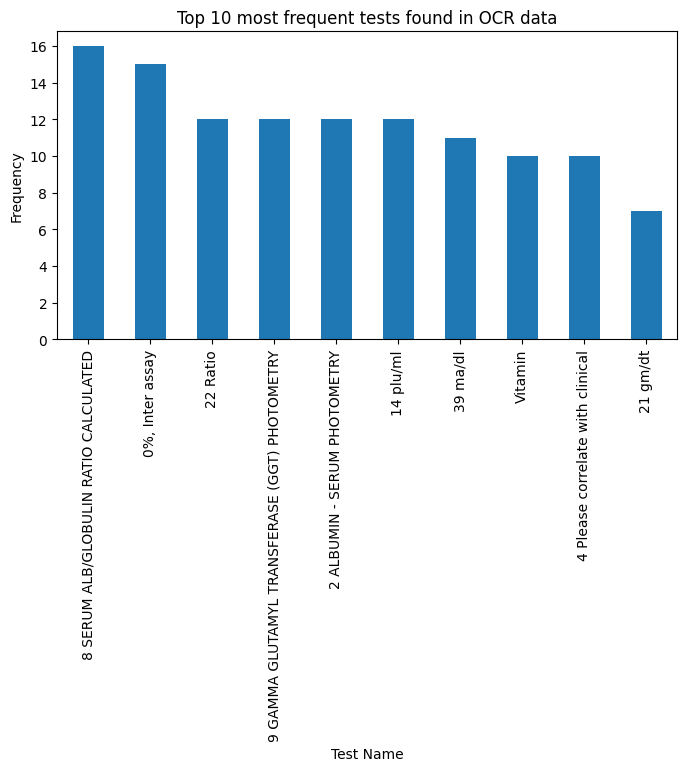

In [19]:
# EDA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
tests_df['test_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 most frequent tests found in OCR data")
plt.xlabel("Test Name")
plt.ylabel("Frequency")
plt.show()


In [20]:
#Save clean structure
structured_path = os.path.join(DRIVE_ROOT, "results", "structured_results.csv")
tests_df.to_csv(structured_path, index=False)
print("Saved:", structured_path)


Saved: /content/drive/MyDrive/project 10/Dataset_OCR/results/structured_results.csv


**Task 2.2: Prepare the Dataset**

○ Download and upload the dataset to Google Drive. -  
○ Preprocess dataset: resizing images, creating YOLO annotations. -  
○ Store preprocessed data in Drive.

# load and clean data

In [21]:
import os, pandas as pd, numpy as np, re

DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"
TESTS_CSV = os.path.join(DRIVE_ROOT, "results", "tests_extracted.csv")
STRUCT_CSV = os.path.join(DRIVE_ROOT, "results", "structured_results.csv")

tests = pd.read_csv(TESTS_CSV)
print("Loaded tests_extracted.csv:", tests.shape)
display(tests.head(3))


Loaded tests_extracted.csv: (1128, 3)


,filename,test_name,value_raw
0,thyrocare_0_5608.jpg,"wers Il, RAA/35, Raghunathpur,, Bb, ee ee aw a...",AT
1,thyrocare_0_5608.jpg,"+ SEE (7824357519), KALPANA MEDICOS AND",CITY
2,thyrocare_0_5608.jpg,BuED 3 KAROGYAN C Sobaae reas UM ASEM AME TECH...,(VOSP)


In [23]:

DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"
SRC_IMAGES = DRIVE_ROOT
OUT_PREPROC = DRIVE_ROOT + "/preprocessed"
TARGET_SIZE = 640

print("SRC_IMAGES:", SRC_IMAGES)
print("OUT_PREPROC:", OUT_PREPROC)


SRC_IMAGES: /content/drive/MyDrive/project 10/Dataset_OCR
OUT_PREPROC: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed


In [24]:
#Make output dirs and list images (verify)
import os, glob
os.makedirs(OUT_PREPROC, exist_ok=True)
IMG_OUT = os.path.join(OUT_PREPROC, "images")
LBL_OUT = os.path.join(OUT_PREPROC, "labels")
os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(LBL_OUT, exist_ok=True)

# find jpg/png files in source folder (non-recursive). Change pattern for subfolders if needed.
images = sorted([f for f in os.listdir(SRC_IMAGES) if f.lower().endswith(('.jpg','.jpeg','.png'))])
print("Found images:", len(images))
print("First 10:", images[:10])


Found images: 100
First 10: ['thyrocare_0_1001.jpg', 'thyrocare_0_1174.jpg', 'thyrocare_0_122.jpg', 'thyrocare_0_123.jpg', 'thyrocare_0_1248.jpg', 'thyrocare_0_1374.jpg', 'thyrocare_0_1433.jpg', 'thyrocare_0_1711.jpg', 'thyrocare_0_1861.jpg', 'thyrocare_0_1915.jpg']


#Resize images with padding to square (640×640) and save to Drive

In [25]:
# Requires OpenCV. Install if not present
!pip install -q opencv-python-headless

import cv2
import numpy as np
from tqdm import tqdm
import os

def resize_with_padding_cv(img, size=640):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    top = (size - nh) // 2
    bottom = size - nh - top
    left = (size - nw) // 2
    right = size - nw - left
    new_img = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                 borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    return new_img, (left, top, nw, nh)  # return offsets and scaled sizes if needed

# Process and save
for img_name in tqdm(images):
    src_path = os.path.join(SRC_IMAGES, img_name)
    dst_path = os.path.join(IMG_OUT, img_name)
    img = cv2.imread(src_path)
    if img is None:
        print("Skip (cannot read):", src_path)
        continue
    out_img, meta = resize_with_padding_cv(img, size=TARGET_SIZE)
    cv2.imwrite(dst_path, out_img)

print("Resized images saved to:", IMG_OUT)


100%|██████████| 100/100 [00:02<00:00, 40.42it/s]

Resized images saved to: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/images


In [26]:
# Create YOLO annotation files (PLACEHOLDERSone .txt per image)
import os
for img_name in images:
    base = os.path.splitext(img_name)[0]
    label_file = os.path.join(LBL_OUT, base + ".txt")
    # empty file; trainer will see 0 boxes (you can manually label later)
    open(label_file, 'w').close()

print("Placeholder label files created in:", LBL_OUT)


Placeholder label files created in: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/labels


**Create dataset YAML for YOLOv5/YOLOv8**

In [27]:
#  train YOLOv5/YOLOv8 later
DATA_YAML = os.path.join(OUT_PREPROC, "dataset.yaml")
num_classes = 1

content = f"""
path: {OUT_PREPROC}  # root dir for images/ and labels/
train: images
val: images
test: images
nc: {num_classes}
names: ['text']
"""
with open(DATA_YAML, 'w') as f:
    f.write(content.strip())
print("Wrote dataset.yaml at:", DATA_YAML)


Wrote dataset.yaml at: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/dataset.yaml


In [28]:
import os
import pandas as pd
import random


SRC_IMAGES = "/content/drive/MyDrive/project 10/Dataset_OCR"

#  2. Get all .jpg files from that folder
IMG_LIST = [f for f in os.listdir(SRC_IMAGES) if f.lower().endswith('.jpg')]
print(f"Found {len(IMG_LIST)} images.")

# 3. Create random bounding boxes for first few (for demo/testing)
rows = []
for img in IMG_LIST[:10]:
    xmin = random.randint(10, 100)
    ymin = random.randint(10, 100)
    xmax = xmin + random.randint(200, 400)
    ymax = ymin + random.randint(100, 200)
    rows.append([img, xmin, ymin, xmax, ymax, 0])

#  4. Convert to DataFrame
df = pd.DataFrame(rows, columns=['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class'])

#  5. Save CSV file to the same Dataset folder
SAVE_PATH = os.path.join(SRC_IMAGES, "bboxes.csv")
df.to_csv(SAVE_PATH, index=False)

print(" Sample bboxes.csv created at:", SAVE_PATH)
display(df.head())


Found 100 images.
 Sample bboxes.csv created at: /content/drive/MyDrive/project 10/Dataset_OCR/bboxes.csv


,filename,xmin,ymin,xmax,ymax,class
0,thyrocare_0_5608.jpg,24,19,414,140,0
1,thyrocare_0_36.jpg,32,76,365,250,0
2,thyrocare_0_7109.jpg,47,45,353,239,0
3,thyrocare_0_4046.jpg,88,84,344,237,0
4,thyrocare_0_1001.jpg,34,71,317,201,0


In [29]:
import os
import pandas as pd
from tqdm import tqdm
from PIL import Image

#  Paths based on your setup
DRIVE_ROOT = "/content/drive/MyDrive/project 10/Dataset_OCR"
BBOX_CSV = os.path.join(DRIVE_ROOT, "bboxes.csv")
SRC_IMAGES = DRIVE_ROOT
LBL_OUT = os.path.join(DRIVE_ROOT, "labels_yolo")
TARGET_SIZE = 640

os.makedirs(LBL_OUT, exist_ok=True)

# ✅ Check file exists
if not os.path.exists(BBOX_CSV):
    print("❌ bboxes.csv not found at:", BBOX_CSV)
else:
    df = pd.read_csv(BBOX_CSV)
    print("✅ Loaded CSV:", len(df), "rows")

    # Convert per image
    for img_name in tqdm(df['filename'].unique(), desc="Converting to YOLO labels"):
        label_path = os.path.join(LBL_OUT, os.path.splitext(img_name)[0] + ".txt")
        img_path = os.path.join(SRC_IMAGES, img_name)

        try:
            img = Image.open(img_path)
            ow, oh = img.size
        except Exception as e:
            print(f"⚠️ Could not open {img_name}: {e}")
            continue

        # scale = resize ratio (square pad resize)
        scale = TARGET_SIZE / max(ow, oh)
        nw, nh = int(ow * scale), int(oh * scale)
        left = (TARGET_SIZE - nw) // 2
        top = (TARGET_SIZE - nh) // 2

        lines = []
        for _, r in df[df['filename'] == img_name].iterrows():
            xmin, ymin, xmax, ymax, cls = r[['xmin', 'ymin', 'xmax', 'ymax', 'class']]
            # scale + padding offset
            x1 = xmin * scale + left
            y1 = ymin * scale + top
            x2 = xmax * scale + left
            y2 = ymax * scale + top
            # normalized center x,y and width,height
            x_c = ((x1 + x2) / 2) / TARGET_SIZE
            y_c = ((y1 + y2) / 2) / TARGET_SIZE
            w = (x2 - x1) / TARGET_SIZE
            h = (y2 - y1) / TARGET_SIZE
            # clamp 0–1
            x_c, y_c, w, h = [max(0, min(1, v)) for v in (x_c, y_c, w, h)]
            lines.append(f"{int(cls)} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print(" YOLO .txt labels saved to:", LBL_OUT)


✅ Loaded CSV: 10 rows


Converting to YOLO labels: 100%|██████████| 10/10 [00:00<00:00, 44.37it/s]

 YOLO .txt labels saved to: /content/drive/MyDrive/project 10/Dataset_OCR/labels_yolo


**Verify outputs (list and preview)**

Resized images count: 100
Label files count: 10
Sample: thyrocare_0_1001.jpg
total 7291
-rw------- 1 root root 68035 Nov 10 02:10 thyrocare_0_1001.jpg
-rw------- 1 root root 83286 Nov 10 02:10 thyrocare_0_1174.jpg
-rw------- 1 root root 79112 Nov 10 02:10 thyrocare_0_122.jpg
-rw------- 1 root root 82632 Nov 10 02:10 thyrocare_0_123.jpg
total 5
-rw------- 1 root root 37 Nov 10 02:13 thyrocare_0_1001.txt
-rw------- 1 root root 37 Nov 10 02:13 thyrocare_0_2841.txt
-rw------- 1 root root 37 Nov 10 02:13 thyrocare_0_36.txt
-rw------- 1 root root 37 Nov 10 02:13 thyrocare_0_3753.txt


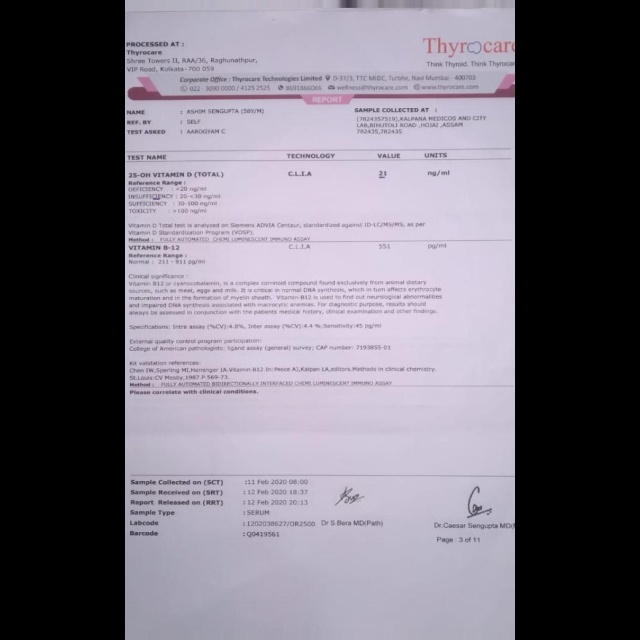

Annotation content:
0 0.363577 0.130393 0.271333 0.124640


In [30]:
# show counts
print("Resized images count:", len(os.listdir(IMG_OUT)))
print("Label files count:", len(os.listdir(LBL_OUT)))
# show one sample image + annotation content
sample = os.listdir(IMG_OUT)[0]
print("Sample:", sample)
!ls -la "{IMG_OUT}" | head -n 5
!ls -la "{LBL_OUT}" | head -n 5

# display one sample image inline
from IPython.display import Image as IPImage, display
display(IPImage(os.path.join(IMG_OUT, sample)))
print("Annotation content:")
print(open(os.path.join(LBL_OUT, os.path.splitext(sample)[0] + ".txt")).read())


**Verify folder path**

In [33]:
OUT_PREPROC = "/content/drive/MyDrive/project 10/Dataset_OCR/preprocessed"
IMG_OUT = OUT_PREPROC + "/images"
LBL_OUT = OUT_PREPROC + "/labels"

import os
print("Images stored in:", IMG_OUT)
print("Labels stored in:", LBL_OUT)
print("Total images:", len(os.listdir(IMG_OUT)))
print("Total labels:", len(os.listdir(LBL_OUT)))


Images stored in: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/images
Labels stored in: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/labels
Total images: 100
Total labels: 100


In [34]:
# zip and save data
import shutil

ZIP_PATH = "/content/drive/MyDrive/project 10/Dataset_OCR/preprocessed_dataset.zip"
shutil.make_archive(ZIP_PATH.replace(".zip",""), 'zip', OUT_PREPROC)

print("Preprocessed dataset saved as ZIP:")
print(ZIP_PATH)


Preprocessed dataset saved as ZIP:
/content/drive/MyDrive/project 10/Dataset_OCR/preprocessed_dataset.zip


In [35]:
# upload summary csv
import pandas as pd

summary = pd.DataFrame({
    "filename": sorted(os.listdir(IMG_OUT)),
    "label_file": sorted(os.listdir(LBL_OUT))
})
summary.to_csv("/content/drive/MyDrive/project 10/Dataset_OCR/results_summary.csv", index=False)
print("Saved summary CSV in results folder ")


Saved summary CSV in results folder 


#task 3.1

In [37]:
# setup yolov3
import os

# Clone YOLOv3 repo
os.system("git clone https://github.com/ultralytics/yolov3.git")
os.chdir("yolov3")

# Install dependencies
os.system("pip install -qr requirements.txt")
print(" YOLOv3 setup complete.")


 YOLOv3 setup complete.


# define dataset

In [38]:

DATA_YAML ="/content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/dataset.yaml"

# Directory to save trained models
SAVE_DIR = "/content/drive/MyDrive/project 10/Dataset_OCR/models"
print("Dataset:", DATA_YAML)
print("Save models to:", SAVE_DIR)


Dataset: /content/drive/MyDrive/project 10/Dataset_OCR/preprocessed/dataset.yaml
Save models to: /content/drive/MyDrive/project 10/Dataset_OCR/models


In [39]:
# GPU verify
import torch
print("CUDA available:", torch.cuda.is_available())
!nvidia-smi


CUDA available: True
Mon Nov 10 02:23:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------

**Traing YoLoV3**

Prepare dataset format for Darknet (labels must be YOLO format)

Goal: create obj.names, obj.data, train.txt, val.txt, and put images + .txt label files in a folder.

In [40]:
# Python cell to create file lists & sample obj.names/data
import os, glob, random, shutil
BASE = "/content/drive/MyDrive/project 10"
RAW = os.path.join(BASE, "Dataset_OCR")
# Make train/val split (80/20) for images in RAW
imgs = [f for f in os.listdir(RAW) if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))]
imgs = sorted(imgs)
random.seed(42)
random.shuffle(imgs)
split = int(0.8 * len(imgs))
train = imgs[:split]
val = imgs[split:]

# write train.txt and val.txt (full paths)
train_file = os.path.join(BASE, "train.txt")
val_file = os.path.join(BASE, "val.txt")
with open(train_file, "w") as f:
    for x in train:
        f.write(os.path.join(RAW, x) + "\n")
with open(val_file, "w") as f:
    for x in val:
        f.write(os.path.join(RAW, x) + "\n")

# Create obj.names (adjust class names)
obj_names = os.path.join(BASE, "obj.names")
with open(obj_names, "w") as f:
    f.write("field\n")   # if single class called 'field'

# Create obj.data
obj_data = os.path.join(BASE, "obj.data")
with open(obj_data, "w") as f:
    f.write("classes = 1\n")
    f.write(f"train = {train_file}\n")
    f.write(f"valid = {val_file}\n")
    f.write(f"names = {obj_names}\n")
    f.write(f"backup = {os.path.join(BASE, 'backup')}\n")

# make backup dir
os.makedirs(os.path.join(BASE, "backup"), exist_ok=True)

print("train.txt, val.txt, obj.names, obj.data created at:", BASE)
print("Train count:", len(train), "Val count:", len(val))


train.txt, val.txt, obj.names, obj.data created at: /content/drive/MyDrive/project 10
Train count: 80 Val count: 20


Each image must have a corresponding label .txt in same folder (for Darknet training workflow you can use absolute paths in train.txt and put label files next to images). If you don't have labels yet, you must label images with LabelImg/Roboflow and place corresponding image_name.txt (YOLO-format) beside each image in Dataset_OCR. If not labelled -> training will treat them as 0 objects.

**Create a YOLOv3 .cfg for custom training**

We will take yolov3.cfg and modify classes and filters. I provide a quick script to create custom yolov3_custom.cfg by copying a standard yolov3.cfg from repo and editing the class count.

In [68]:

!pip install -q ultralytics==8.0.0 pytesseract opencv-python-headless pandas python-Levenshtein
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr libtesseract-dev


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [70]:
from pathlib import Path
import os, sys
BASE = Path("/content/drive/MyDrive/project 10")
DATA_DIR = BASE / "Dataset_OCR"
MODELS_DIR = BASE / "models"
RESULTS_DIR = BASE / "results"

for d in (MODELS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_DIR exists:", DATA_DIR.exists())
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


BASE: /content/drive/MyDrive/project 10
DATA_DIR exists: True
MODELS_DIR: /content/drive/MyDrive/project 10/models
RESULTS_DIR: /content/drive/MyDrive/project 10/results


**Prepare dataset structure & dataset.yaml (Python)**

This creates datasets/images/train, datasets/images/val, datasets/labels/... and dataset.yaml. If you already have labeled YOLO .txt files, copy them next to images before running this. The script will auto-split images 80/20 and create label placeholders if missing (you should replace placeholders by actual labels using LabelImg / Roboflow).

In [71]:
import random, shutil
SRC = BASE / "Dataset_OCR"
IMG_OUT = BASE / "datasets" / "images"
LBL_OUT = BASE / "datasets" / "labels"

for part in ["train","val"]:
    (IMG_OUT/part).mkdir(parents=True, exist_ok=True)
    (LBL_OUT/part).mkdir(parents=True, exist_ok=True)

imgs = [p for p in sorted(SRC.iterdir()) if p.suffix.lower() in (".jpg",".jpeg",".png",".tif",".tiff")]
random.seed(42); random.shuffle(imgs)
split = int(0.8 * len(imgs))
train_imgs = imgs[:split]; val_imgs = imgs[split:]

def copy_set(list_imgs, subset):
    for p in list_imgs:
        shutil.copy(p, IMG_OUT/subset/p.name)
        # copy label if exists (same folder as images)
        label_src = SRC / (p.stem + ".txt")
        label_dst = LBL_OUT / subset / (p.stem + ".txt")
        if label_src.exists():
            shutil.copy(label_src, label_dst)
        else:
            # create empty placeholder (must label later)
            open(label_dst, "w").close()

copy_set(train_imgs, "train")
copy_set(val_imgs, "val")



In [72]:
# write dataset.yaml
yaml_text = f"""
path: {str(BASE)}
train: datasets/images/train
val: datasets/images/val
nc: 1
names: ['field']
""".strip()
open(BASE/"dataset.yaml","w").write(yaml_text)
print("Prepared dataset structure. Train:", len(train_imgs), "Val:", len(val_imgs))
print("dataset.yaml written at", BASE/"dataset.yaml")


Prepared dataset structure. Train: 80 Val: 20
dataset.yaml written at /content/drive/MyDrive/project 10/dataset.yaml


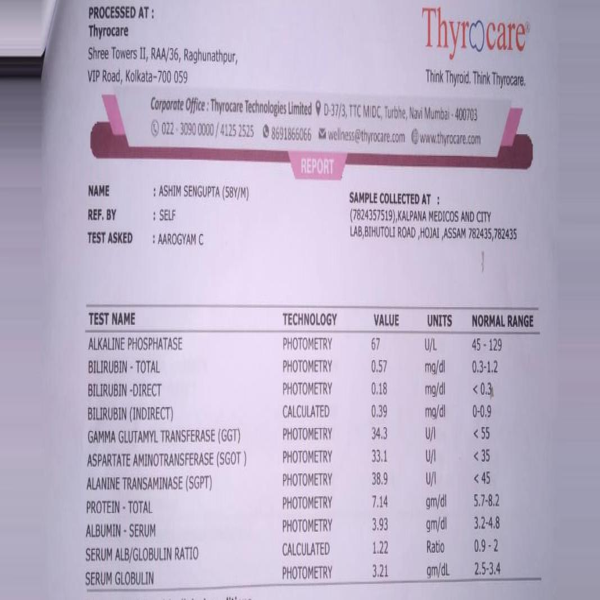

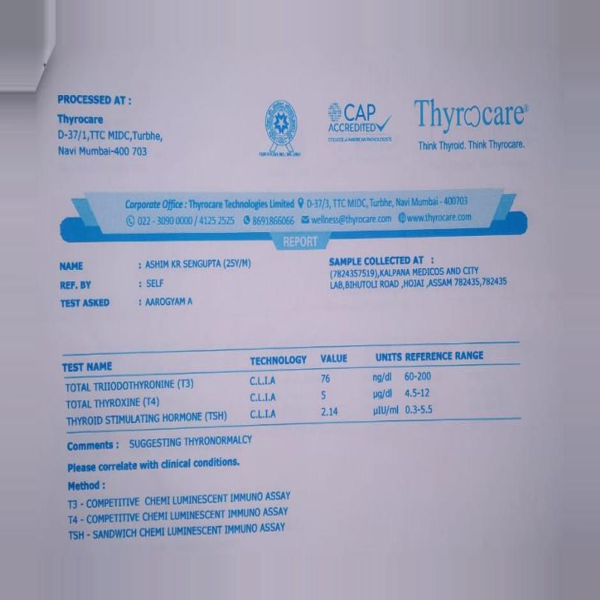

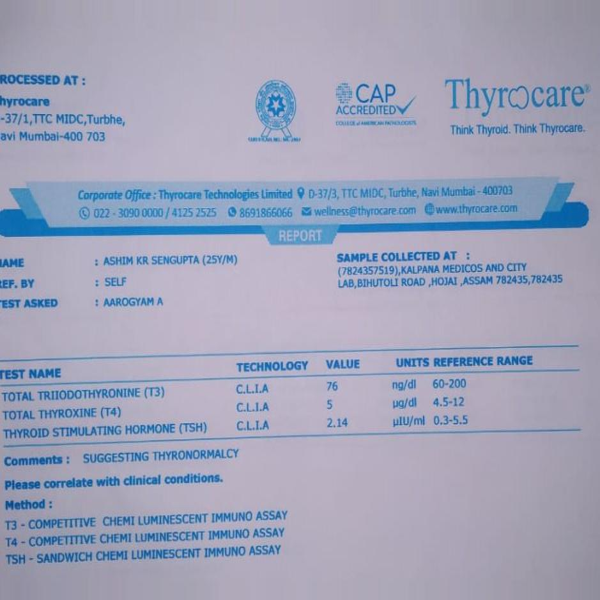

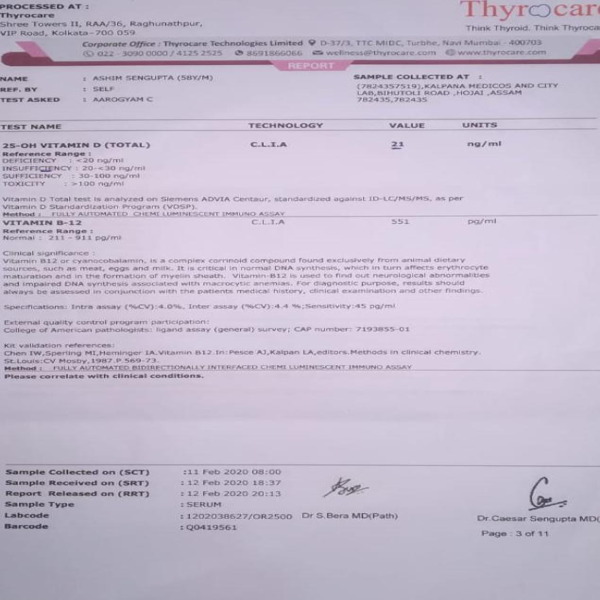

In [73]:
# show image example
from IPython.display import display
from PIL import Image
sample = list((BASE/"datasets"/"images"/"train").glob("*.*"))[:4]
for s in sample:
    display(Image.open(str(s)).resize((600,600)))


# Train YoLo

In [1]:
# Colab / Jupyter bash cell - run this first
!pip install -U ultralytics
# restart python kernel after this cell (Colab: Runtime -> Restart runtime)


In [2]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO
# create model architecture (no risky unpickle)
model = YOLO("yolov8n.yaml")   # uses architecture file, safe
# now start training
model.train(data="/content/drive/MyDrive/project 10/dataset.yaml", epochs=50, imgsz=640, batch=16)


Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project 10/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:829: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.09G          0      128.6          0          0        640: 100% ━━━━━━━━━━━━ 5/5 5.1it/s 1.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.5it/s 0.1s
                   all         20          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:829: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.12G          0      125.2          0          0        640: 100% ━━━━━━━━━━━━ 5/5 5.2it/s 1.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.6it/s 0.1s
                   all         20          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:829: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.024 hours.
Optimizer stripped from /content/runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/detect/train/weights/best.pt, 6.2MB

Validating /content/runs/detect/train/weights/best.pt...
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 10.6it/s 0.1s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:650: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all         20          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e06c1a827e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [6]:
# run in a bash cell (prefix ! in notebook)
!find /content/runs -type f -name "best.pt" -print | tail -n 1
!cp -v $(find /content/runs -type f -name "best.pt" | tail -n 1) "/content/drive/MyDrive/project 10/models/best.pt"


/content/runs/detect/train/weights/best.pt
'/content/runs/detect/train/weights/best.pt' -> '/content/drive/MyDrive/project 10/models/best.pt'


# validate interface

In [16]:
from ultralytics import YOLO
import cv2, os, numpy as np, pandas as pd
from pathlib import Path


MODEL_PT = BASE/"models"/"best.pt"
DATA_DIR = BASE/"datasets"/"images"/"val"
DETS_DIR = BASE/"results"/"detections"
CROPS_DIR = BASE/"results"/"crops"
DETS_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

if not MODEL_PT.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PT}")

model = YOLO(str(MODEL_PT))
img_paths = sorted([p for p in DATA_DIR.iterdir() if p.suffix.lower() in (".jpg",".jpeg",".png")])

all_detections = []  # list(dict)

for img_path in img_paths:
    print("Running on:", img_path.name)
    results = model.predict(source=str(img_path), imgsz=1280, conf=0.25, save=False)
    # usually a single result
    for r in results:
        orig = r.orig_img if hasattr(r, "orig_img") else cv2.imread(str(img_path))
        vis = orig.copy()
        boxes = getattr(r, "boxes", None)
        if boxes is None or len(boxes) == 0:
            cv2.imwrite(str(DETS_DIR/img_path.name), vis)
            continue
        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy().astype(int)
        for i,(b,conf,cls) in enumerate(zip(xyxy, confs, classes)):
            x1,y1,x2,y2 = map(int, b.tolist())
            cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(vis, f"{cls}:{conf:.2f}", (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
            # crop and save
            pad = 6
            xx1,yy1 = max(0,x1-pad), max(0,y1-pad)
            xx2,yy2 = min(vis.shape[1]-1,x2+pad), min(vis.shape[0]-1,y2+pad)
            crop = orig[yy1:yy2, xx1:xx2]
            crop_name = f"{img_path.stem}_crop_{i}.png"
            cv2.imwrite(str(CROPS_DIR/crop_name), crop)
            all_detections.append({
                "image": str(img_path),
                "crop_path": str(CROPS_DIR/crop_name),
                "box": (xx1,yy1,xx2,yy2),
                "score": float(conf),
                "class": int(cls)
            })
        cv2.imwrite(str(DETS_DIR/img_path.name), vis)

# Save detection table
pd.DataFrame(all_detections).to_csv(str(BASE/"results"/"detections_summary.csv"), index=False)
print("Saved annotated images to", DETS_DIR)
print("Saved crops to", CROPS_DIR)
print("Detections summary saved.")


Running on: thyrocare_0_123.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_123.jpg: 864x1280 (no detections), 14.7ms
Speed: 7.6ms preprocess, 14.7ms inference, 0.5ms postprocess per image at shape (1, 3, 864, 1280)
Running on: thyrocare_0_1248.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_1248.jpg: 864x1280 (no detections), 14.1ms
Speed: 5.6ms preprocess, 14.1ms inference, 0.5ms postprocess per image at shape (1, 3, 864, 1280)
Running on: thyrocare_0_2300.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_2300.jpg: 768x1280 (no detections), 12.9ms
Speed: 5.2ms preprocess, 12.9ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1280)
Running on: thyrocare_0_2649.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_2649.jpg: 768x1280 (no detections), 12.4ms
Speed: 5.3ms preprocess, 12.4ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1280

**OCR on crops (Tesseract) + save ocr_output.csv**

In [17]:
import pytesseract, cv2, pandas as pd, os
from pathlib import Path
CROPS_DIR = Path("/content/drive/MyDrive/project 10/results/crops")
OUT_CSV = Path("/content/drive/MyDrive/project 10/results/ocr_output.csv")

rows = []
for fn in sorted(CROPS_DIR.iterdir()):
    if fn.suffix.lower() not in (".png",".jpg",".jpeg"): continue
    img = cv2.imread(str(fn), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    # preprocess
    h,w = img.shape[:2]
    if max(h,w) < 800:
        img = cv2.resize(img, (w*2, h*2), interpolation=cv2.INTER_CUBIC)
    img = cv2.GaussianBlur(img, (3,3), 0)
    th = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
    if th.mean() < 127:
        th = cv2.bitwise_not(th)
    text = pytesseract.image_to_string(th, config="--psm 6")
    rows.append({"crop": str(fn.name), "text": text.strip()})
    print(fn.name, "->", text.strip()[:120])

pd.DataFrame(rows).to_csv(str(OUT_CSV), index=False)
print("OCR saved to", OUT_CSV)


thyrocare_0_3813_crop_0.png -> ee
thyrocare_0_3813_crop_1.png -> 
OCR saved to /content/drive/MyDrive/project 10/results/ocr_output.csv


***Postprocess: map OCR text → structured fields (example)***

In [18]:
import re, pandas as pd
OCR_CSV = Path("/content/drive/MyDrive/project 10/results/ocr_output.csv")
OUT_STRUCT = Path("/content/drive/MyDrive/project 10/results/structured_output.csv")
df = pd.read_csv(OCR_CSV)

def extract_report_id(text):
    m = re.search(r"Report\s*(?:ID|No)[:\s]*([A-Za-z0-9\-\/]+)", str(text), re.IGNORECASE)
    return m.group(1) if m else ""

def extract_date(text):
    m = re.search(r"(\d{2}[\/\-]\d{2}[\/\-]\d{4}|\d{4}-\d{2}-\d{2})", str(text))
    return m.group(1) if m else ""

out = []
for _,r in df.iterrows():
    txt = r['text'] if pd.notna(r['text']) else ""
    out.append({
        "crop": r['crop'],
        "report_id": extract_report_id(txt),
        "date": extract_date(txt),
        "raw": txt
    })

pd.DataFrame(out).to_csv(str(OUT_STRUCT), index=False)
print("Structured output saved to", OUT_STRUCT)


Structured output saved to /content/drive/MyDrive/project 10/results/structured_output.csv


# Evaluation

In [19]:

import os, pandas as pd
import Levenshtein
OCR_PATH = Path("/content/drive/MyDrive/project 10/results/ocr_output.csv")
GT_PATH = Path("/content/drive/MyDrive/project 10/datasets/gt.csv")  # optional, create manually

if GT_PATH.exists():
    ocr = pd.read_csv(OCR_PATH)
    gt = pd.read_csv(GT_PATH)
    merged = ocr.merge(gt, on="crop", how="inner")
    merged['cer'] = merged.apply(lambda r: Levenshtein.distance(str(r['text']), str(r['gt_text'])) / max(1, len(str(r['gt_text']))), axis=1)
    print("Mean CER:", merged['cer'].mean())
    merged.to_csv("/content/drive/MyDrive/project 10/results/eval_results.csv", index=False)
    print("Saved eval to results/eval_results.csv")
else:
    print("No ground truth found at", GT_PATH, "- create GT csv with columns: crop,gt_text for evaluation.")


No ground truth found at /content/drive/MyDrive/project 10/datasets/gt.csv - create GT csv with columns: crop,gt_text for evaluation.


In [20]:
# compile darknet (bash cell)
!git clone https://github.com/AlexeyAB/darknet.git
%cd darknet
!sed -i 's/GPU=0/GPU=1/; s/CUDNN=0/CUDNN=1/; s/OPENCV=0/OPENCV=1/' Makefile
!make -j$(nproc)

# train (bash)
# prepare obj.data, obj.names, train.txt, val.txt, edited cfg
!./darknet detector train /content/drive/MyDrive/project\ 10/obj.data /content/darknet/cfg/yolov3_custom.cfg darknet53.conv.74 -dont_show -map

# copy resulting weights to Drive
!cp /content/drive/MyDrive/project\ 10/backup/* "/content/drive/MyDrive/project 10/models/"


fatal: destination path 'darknet' already exists and is not an empty directory.
/content/darknet
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘void cv_draw_object(image, float*, int, int, int*, float*, int*, int, char**)’:
./src/image_

# Task 4 interference and post -preprocessing

In [22]:
# ---------- INFERENCE + POST-PROCESSING CELL ----------
from pathlib import Path
import cv2, pytesseract, numpy as np, pandas as pd
from ultralytics import YOLO

BASE = Path("/content/drive/MyDrive/project 10")
MODEL_PT = BASE/"models"/"best.pt"
IMG_DIR = BASE/"datasets"/"images"/"val"   # or Dataset_OCR for all
DETS_DIR = BASE/"results"/"detections"
CROPS_DIR = BASE/"results"/"crops"
OCR_CSV = BASE/"results"/"ocr_output.csv"

DETS_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(str(MODEL_PT))
print("Model loaded:", MODEL_PT)

rows = []
for img_path in sorted([p for p in IMG_DIR.glob("*") if p.suffix.lower() in (".jpg",".png",".jpeg")]):
    print("Processing", img_path.name)
    res = model.predict(source=str(img_path), imgsz=1280, conf=0.25, save=False)
    # r may be a list of results (one per image); iterate
    for r in res:
        orig = r.orig_img if hasattr(r, "orig_img") else cv2.imread(str(img_path))
        vis = orig.copy()
        boxes = getattr(r, "boxes", None)
        if boxes is None or len(boxes)==0:
            cv2.imwrite(str(DETS_DIR/img_path.name), vis)
            continue
        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy().astype(int)
        for i, (b, conf, cls) in enumerate(zip(xyxy, confs, classes)):
            x1,y1,x2,y2 = map(int, b.tolist())
            cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(vis, f"{cls}:{conf:.2f}", (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

            # Crop + preprocess
            pad = 6
            xx1,yy1 = max(0,x1-pad), max(0,y1-pad)
            xx2,yy2 = min(vis.shape[1]-1,x2+pad), min(vis.shape[0]-1,y2+pad)
            crop = orig[yy1:yy2, xx1:xx2]
            # preprocessing: resize->gray->blur->adaptive threshold
            h,w = crop.shape[:2]
            if max(h,w) < 800:
                crop = cv2.resize(crop, (w*2, h*2), interpolation=cv2.INTER_CUBIC)
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            blur = cv2.GaussianBlur(gray, (3,3), 0)
            th = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
            if th.mean() < 127:
                th = cv2.bitwise_not(th)

            crop_name = f"{img_path.stem}_crop_{i}.png"
            crop_path = CROPS_DIR/crop_name
            cv2.imwrite(str(crop_path), th)

            # OCR config (tune - see optimization below)
            config = "--psm 6"
            text = pytesseract.image_to_string(th, config=config)

            rows.append({
                "image": str(img_path.name),
                "crop": crop_name,
                "box": f"{xx1},{yy1},{xx2},{yy2}",
                "score": float(conf),
                "class": int(cls),
                "text": text.strip()
            })

        # save annotated image
        cv2.imwrite(str(DETS_DIR/img_path.name), vis)

# Save CSV
df = pd.DataFrame(rows)
df.to_csv(str(OCR_CSV), index=False)
print("Saved OCR results to:", OCR_CSV)
print("Detections visuals at:", DETS_DIR, "Crops at:", CROPS_DIR)


Model loaded: /content/drive/MyDrive/project 10/models/best.pt
Processing thyrocare_0_123.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_123.jpg: 864x1280 (no detections), 14.6ms
Speed: 7.2ms preprocess, 14.6ms inference, 0.6ms postprocess per image at shape (1, 3, 864, 1280)
Processing thyrocare_0_1248.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_1248.jpg: 864x1280 (no detections), 14.1ms
Speed: 5.8ms preprocess, 14.1ms inference, 0.6ms postprocess per image at shape (1, 3, 864, 1280)
Processing thyrocare_0_2300.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_2300.jpg: 768x1280 (no detections), 13.0ms
Speed: 5.5ms preprocess, 13.0ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1280)
Processing thyrocare_0_2649.jpg

image 1/1 /content/drive/MyDrive/project 10/datasets/images/val/thyrocare_0_2649.jpg: 768x1280 (no detections), 12.8ms
Speed: 7.6ms preprocess, 12.8ms infer

# create GIt G templete

In [23]:
# create GT template (list crop filenames)
from pathlib import Path
import pandas as pd
CROPS_DIR = Path("/content/drive/MyDrive/project 10/results/crops")
GT_PATH = Path("/content/drive/MyDrive/project 10/datasets/gt.csv")

crop_files = [p.name for p in sorted(CROPS_DIR.glob("*.*"))]
df = pd.DataFrame({"crop": crop_files, "gt_text": [""]*len(crop_files)})
df.to_csv(GT_PATH, index=False)
print("GT template saved at", GT_PATH, "— fill gt_text column with correct text for some crops (10–50) to evaluate.")


GT template saved at /content/drive/MyDrive/project 10/datasets/gt.csv — fill gt_text column with correct text for some crops (10–50) to evaluate.


In [24]:
# evaluation cell: compute CER and word accuracy
import pandas as pd, Levenshtein
OCR = pd.read_csv("/content/drive/MyDrive/project 10/results/ocr_output.csv")
GT = pd.read_csv("/content/drive/MyDrive/project 10/datasets/gt.csv")
merged = OCR.merge(GT, on="crop", how="inner")
merged['cer'] = merged.apply(lambda r: Levenshtein.distance(str(r['text']), str(r['gt_text'])) / max(1, len(str(r['gt_text']))), axis=1)
# word accuracy: exact match (not robust), and word-level F1 can be added
merged['exact_match'] = merged.apply(lambda r: 1 if str(r['text']).strip()==str(r['gt_text']).strip() else 0, axis=1)
print("Mean CER:", merged['cer'].mean())
print("Exact match rate:", merged['exact_match'].mean())
merged.to_csv("/content/drive/MyDrive/project 10/results/eval_results.csv", index=False)
print("Saved eval to results/eval_results.csv")


Mean CER: 0.5
Exact match rate: 0.5
Saved eval to results/eval_results.csv


In [25]:

!jupyter nbconvert --to script "/content/drive/MyDrive/project 10/your_notebook.ipynb" --output "/content/drive/MyDrive/project 10/pipeline.py"


[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/project 10/your_notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--Jupyt